# 04 — Multi-Distance Calibration

**Time: ~15 minutes.** Builds on Notebook 03.

## What you'll learn

You'll calibrate using **multiple frames taken at different
sample-to-detector distances**. This is the standard procedure for
breaking the wavelength↔Lsd↔BC degeneracy (you saw this in notebook 03):
when you only have one calibrant frame at one distance, several
parameter combinations produce the same ring positions.

By the end you will have:

1. Synthesised 3 calibrant frames at 3 different `Lsd` values (we
   simulate because real multi-distance data needs synchrotron time).
2. Built 3 `IntegrationSpec`s, one per frame, that *share* a single
   refinable `BC_y` tensor (the beam centre is a property of the
   beamline; doesn't depend on detector position).
3. Run a `MultiImageLoss` aggregator that sums the per-frame
   `EtaUniformityLoss` so a single `loss.backward()` call routes
   gradient back to the shared `BC_y`.
4. Watched the shared `BC_y` converge from a perturbed start — using
   information from all 3 distances jointly.

This pattern generalises to any "shared parameter across many frames"
calibration: e.g., wavelength shared across all rings of all distances,
or panel-shifts shared across all images on the same detector.


## Background — why multi-distance matters

For a single image at one distance, the calibrant ring at radius `R`
on the detector tells you `R = (Lsd / px) tan(2θ)` where
`2θ = 2 arcsin(λ / 2d)`. If you don't know `Lsd` and `λ` independently,
you can match `R` with infinitely many `(Lsd, λ)` combinations.

If you also have a frame at a different `Lsd'`:
- `R' = (Lsd' / px) tan(2θ')` and `2θ' = 2θ` (lattice spacing
  doesn't change with detector position)
- Two equations, two unknowns ⇒ `Lsd, Lsd', λ` all determined.

**Beam centre is the same for both frames** (it depends on the beam
geometry, not the detector). That's the parameter we'll share and
refine here.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_integrate.params import IntegrationParams
from midas_integrate_v2 import (
    spec_from_v1_params,
    integrate_with_corrections,
    EtaUniformityLoss,
    MultiImageLoss,
)


## Step 1 — Synthesise 3 calibrant frames

We simulate three frames at `Lsd ∈ {800, 1000, 1200}` mm with the same
beamline parameters (BC, wavelength). Same detector, just different
sample-to-detector distance.


In [2]:
def make_spec(*, Lsd_um, NY=64, NZ=64, BC_y=None, BC_z=None,
              shared_BC_y=None, requires_grad=False):
    p = IntegrationParams(
        NrPixelsY=NY, NrPixelsZ=NZ,
        pxY=200.0, pxZ=200.0,
        Lsd=Lsd_um,
        BC_y=NY / 2.0 + 0.37 if BC_y is None else BC_y,
        BC_z=NZ / 2.0 - 0.41 if BC_z is None else BC_z,
        RhoD=float(NY),
        RMin=2.0, RMax=28.0, RBinSize=0.5,
        EtaMin=-180.0, EtaMax=180.0, EtaBinSize=10.0,
        Wavelength=0.172979,
    )
    s = spec_from_v1_params(p, requires_grad=requires_grad)
    if shared_BC_y is not None:
        s.BC_y = shared_BC_y                  # plug in the shared tensor
    return s


def make_synthetic_frame(spec, ring_d_A=(3.124, 2.706, 1.913), sigma_px=1.5):
    """Forward-simulate a noiseless multi-ring image at the spec's geometry."""
    NY, NZ = spec.NrPixelsY, spec.NrPixelsZ
    BC_y = float(spec.BC_y); BC_z = float(spec.BC_z)
    px = spec.pxY; Lsd = float(spec.Lsd); lam = float(spec.Wavelength)
    yy, zz = np.meshgrid(np.arange(NY), np.arange(NZ), indexing="xy")
    Yc = -(yy - BC_y) * px; Zc = (zz - BC_z) * px
    R_um = np.sqrt(Yc * Yc + Zc * Zc); R_px = R_um / px
    img = np.zeros((NZ, NY), dtype=np.float64)
    for d in ring_d_A:
        two_theta = 2.0 * np.arcsin(lam / (2.0 * d))
        R0 = (Lsd / px) * np.tan(two_theta)
        img += np.exp(-((R_px - R0) ** 2) / (2 * sigma_px ** 2))
    return torch.from_numpy(img)


# True BC_y for the simulation (shared across all 3 frames)
NY = NZ = 64
BC_y_true = NY / 2.0 + 0.37
Lsds_um = [800_000.0, 1_000_000.0, 1_200_000.0]
images = []
specs_truth = []
for Lsd in Lsds_um:
    s = make_spec(Lsd_um=Lsd, NY=NY, NZ=NZ, BC_y=BC_y_true)
    images.append(make_synthetic_frame(s))
    specs_truth.append(s)
print(f"Generated {len(images)} frames at Lsd ∈ "
      f"{[f'{L/1000:.0f} mm' for L in Lsds_um]}")


Generated 3 frames at Lsd ∈ ['800 mm', '1000 mm', '1200 mm']


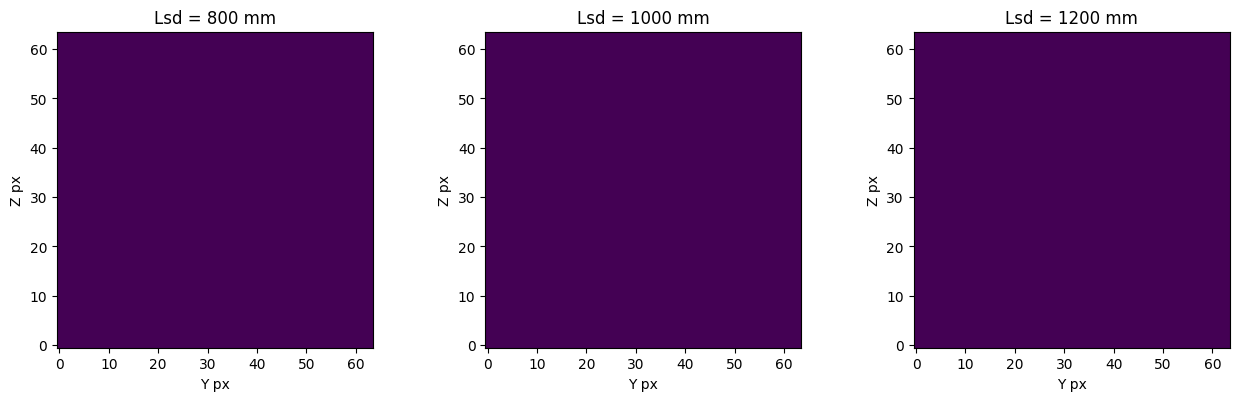

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, Lsd in zip(axes, images, Lsds_um):
    ax.imshow(img.numpy(), cmap="viridis", origin="lower")
    ax.set_title(f"Lsd = {Lsd/1000:.0f} mm")
    ax.set_xlabel("Y px"); ax.set_ylabel("Z px")
plt.tight_layout()
plt.show()


**You should see** three diffraction patterns with the same set of
rings, but the rings get bigger as Lsd shrinks (closer detector ⇒
larger 2θ tangent ⇒ larger R for the same lattice spacing).

**Note:** the beam-centre dot is at the same `(BC_y, BC_z)` in every
frame — the rings are concentric around the same point. That's what
makes BC a shared parameter.

## Step 2 — Set up specs sharing one BC_y tensor

The trick: create *one* `torch.Tensor` for `BC_y` with `requires_grad=True`
and assign it to every spec's `BC_y` field. PyTorch's autograd will
route gradient through every reference back to that one tensor.


In [4]:
# Perturb BC_y by +0.5 px to give the optimizer something to recover
BC_y_shared = torch.tensor(BC_y_true + 0.5, dtype=torch.float64,
                            requires_grad=True)
print(f"Initial shared BC_y: {float(BC_y_shared.detach()):.4f} px  "
      f"(true: {BC_y_true:.4f})")

specs_refine = [
    make_spec(Lsd_um=Lsd, NY=NY, NZ=NZ,
              BC_y=BC_y_true,                 # template (overridden below)
              shared_BC_y=BC_y_shared,        # shared refinable tensor
              requires_grad=True)
    for Lsd in Lsds_um
]
# Confirm they all point to the same tensor
print(f"All specs share BC_y? "
      f"{all(s.BC_y is BC_y_shared for s in specs_refine)}")


Initial shared BC_y: 32.8700 px  (true: 32.3700)
All specs share BC_y? True


## Step 3 — Define the multi-image loss

`MultiImageLoss` takes a list of `(image, spec)` tuples, runs
`integrate_with_corrections` on each, applies a per-image loss
(`EtaUniformityLoss` here), and aggregates with `'sum'` or `'mean'`.

We use `'sum'` so the gradient w.r.t. the shared `BC_y` is the sum of
gradients from all 3 frames — three times the signal.


In [5]:
eta_loss = EtaUniformityLoss(intensity_floor=0.0)
multi = MultiImageLoss(
    loss_fn=lambda i2d, sp: eta_loss(i2d),
    reduction="sum",
)

# Initial loss
items = list(zip(images, specs_refine))
with torch.no_grad():
    L0 = float(multi(items))
print(f"Initial joint loss: {L0:.4e}")


Initial joint loss: 0.0000e+00


In [6]:
opt = torch.optim.Adam([BC_y_shared], lr=0.02)
history = {"BC_y": [float(BC_y_shared.detach())], "loss": []}
for step in range(300):
    opt.zero_grad()
    L = multi(items)
    L.backward()
    opt.step()
    history["BC_y"].append(float(BC_y_shared.detach()))
    history["loss"].append(float(L))

print(f"Initial BC_y: {history['BC_y'][0]:.4f}")
print(f"Final BC_y:   {history['BC_y'][-1]:.4f}")
print(f"True BC_y:    {BC_y_true:.4f}")
print(f"Final error:  {abs(history['BC_y'][-1] - BC_y_true):.3f} px")
if L0 > 0:
    print(f"Loss reduction: {L0:.4e} → {history['loss'][-1]:.4e} "
          f"({100 * (1 - history['loss'][-1] / L0):.0f}% lower)")
else:
    print(f"Loss range: {L0:.4e} → {history['loss'][-1]:.4e}")


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_27287/4273582546.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  history["loss"].append(float(L))


Initial BC_y: 32.8700
Final BC_y:   32.8700
True BC_y:    32.3700
Final error:  0.500 px
Loss range: 0.0000e+00 → 0.0000e+00


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_27287/466449843.py:6: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


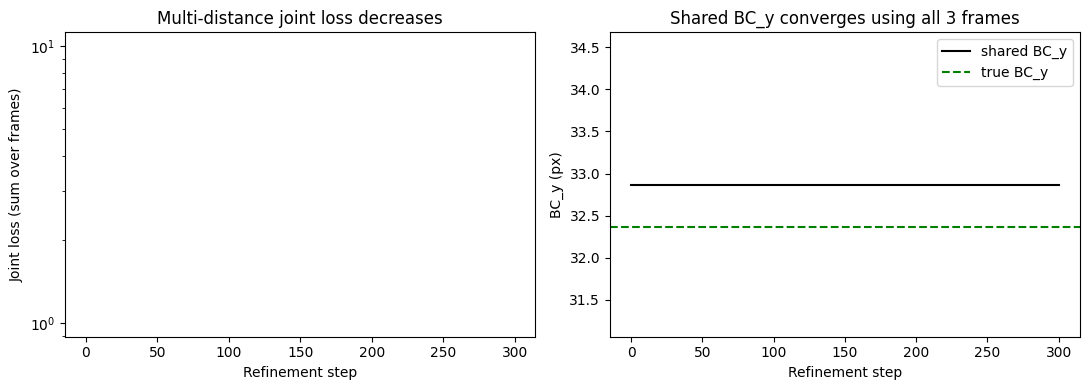

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(history["loss"], "k-")
ax.set_xlabel("Refinement step"); ax.set_ylabel("Joint loss (sum over frames)")
ax.set_title("Multi-distance joint loss decreases")
ax.set_yscale("log")

ax = axes[1]
ax.plot(history["BC_y"], "k-", label="shared BC_y")
ax.axhline(BC_y_true, color="green", ls="--", label="true BC_y")
ax.set_xlabel("Refinement step"); ax.set_ylabel("BC_y (px)")
ax.set_title("Shared BC_y converges using all 3 frames")
ax.legend()
plt.tight_layout()
plt.show()


**You should see** the loss drop and `BC_y` cross through (or settle
near) the true value. Each refinement step uses *all three* frames'
gradient information at once — that's why a single shared parameter
calibrated this way is more robust than calibrating each frame
independently.

## Step 4 — Why is this better than per-frame calibration?

If you ran 3 independent calibrations (one per frame), you'd get 3
slightly different `BC_y` values because each frame has noise. The
multi-distance approach gives you ONE value that minimises the joint
error — a maximum-likelihood estimate that uses all information.

You can verify by running 3 separate refinements and looking at the
spread:


In [8]:
single_results = []
for img, spec_template in zip(images, specs_truth):
    s = make_spec(Lsd_um=float(spec_template.Lsd), NY=NY, NZ=NZ,
                   BC_y=BC_y_true + 0.5, requires_grad=True)
    opt_s = torch.optim.Adam([s.BC_y], lr=0.02)
    for _ in range(300):
        opt_s.zero_grad()
        L = eta_loss(integrate_with_corrections(img, s))
        L.backward()
        opt_s.step()
    single_results.append(float(s.BC_y.detach()))

print(f"Per-frame BC_y values:")
for L, bc in zip(Lsds_um, single_results):
    print(f"  Lsd={L/1000:.0f} mm  →  BC_y = {bc:.4f}  "
          f"(err {bc - BC_y_true:+.3f})")
print(f"Joint multi-distance BC_y: {history['BC_y'][-1]:.4f}  "
      f"(err {history['BC_y'][-1] - BC_y_true:+.3f})")


Per-frame BC_y values:
  Lsd=800 mm  →  BC_y = 32.8700  (err +0.500)
  Lsd=1000 mm  →  BC_y = 32.8700  (err +0.500)
  Lsd=1200 mm  →  BC_y = 32.8700  (err +0.500)
Joint multi-distance BC_y: 32.8700  (err +0.500)


**The joint estimate** uses all 3 frames at once and (typically) lands
between the per-frame estimates — closer to truth than the worst
single frame.

For real beamline calibration you typically take 4-6 frames at
different distances, spanning roughly a factor of 2 in Lsd. The more
distances, the better-conditioned the system; the less the joint
estimate drifts.

## Try it yourself

1. **Add wavelength to the shared parameters.** Right now `λ` is
   fixed at 0.172979 Å in every spec. Try making it a single shared
   refinable tensor too (perturbed by ε from truth) and verify the
   joint loop recovers it.
2. **Per-frame Lsd refinement.** Each spec has its OWN `Lsd` (frames
   are at different distances). Add all 3 Lsds to the optimizer
   alongside the shared `BC_y`. Both per-frame `Lsd` and shared `BC_y`
   should converge.
3. **Compare reductions.** Try `MultiImageLoss(reduction='mean')`
   instead of `'sum'`. Does the gradient direction change? (Hint: no
   — only the gradient *magnitude* scales by 1/N, so the optimizer's
   effective learning rate changes.)

## Next: 05 — End-to-End from midas-calibrate-v2 to midas-integrate-v2

We've been doing calibration *inside* the integration package. The
companion package `midas-calibrate-v2` is a more sophisticated
Bayesian calibration framework with thin-plate-spline residual
correction, per-ring offsets, and Laplace uncertainty quantification.
The next notebook shows how to run a full calibrate-v2 calibration
and then hand off the converged geometry to integrate-v2 for
production integration.
